# Proyecto 3: Limpieza de datos de autos

## Caso adaptado

Se aplica la misma logica del proyecto original de Netflix a un dataset de autos usados. El objetivo es preparar los datos para analizar precios, kilometraje y caracteristicas de los vehiculos.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Revision del dataset

In [31]:
# Leer el dataset adaptado
df_cars = pd.read_csv('autos_para_limpieza.csv')
print(f'Autos cargados: {df_cars.shape[0]}')
df_cars

Autos cargados: 13


,brand,model,year,price,mileage,fuel,transmission
0,Toyota,Corolla,2018,18500.0,62000,Gasolina,Automatica
1,TOYOTA,Camry,2020,24500.0,35000,gasolina,Automatica
2,Ford,Fiesta,2017,12900.0,78000,Gasolina,Manual
3,Honda,Civic,2019,21000.0,41000,Gasolina,Automatica
4,honda,CR-V,2021,28900.0,22000,Hibrido,Automatica
5,Chevrolet,Onix,2020,NaN,30000,Gasolina,Manual
6,Nissan,Versa,2016,9800.0,95000,Gasolina,Manual
7,Mazda,3,2022,27500.0,12000,Gasolina,Automatica
8,Kia,Rio,2015,8500.0,110000,Gasolina,Manual
9,Volkswagen,Jetta,2019,19500.0,54000,Gasolina,NaN


In [32]:
# Revisar tipos y dimensiones
df_cars.dtypes
df_cars.shape

(13, 7)

# 2. Identificar y manejar datos faltantes

In [33]:
# Cantidad y porcentaje de datos faltantes por columna
df_cars.isnull().sum().sort_values(ascending=False)

price           1
transmission    1
brand           0
year            0
model           0
mileage         0
fuel            0
dtype: int64

In [34]:
for column in df_cars.columns:
    percentage = df_cars[column].isnull().mean() * 100
    print(f'{column}: {percentage:.2f}%')

brand: 0.00%
model: 0.00%
year: 0.00%
price: 7.69%
mileage: 0.00%
fuel: 0.00%
transmission: 7.69%


In [35]:
# Completar el precio faltante con la mediana
df_cars['price'] = df_cars['price'].fillna(df_cars['price'].median())

# Completar la transmision faltante con la moda
mode_transmission = df_cars['transmission'].mode()[0]
df_cars['transmission'] = df_cars['transmission'].fillna(mode_transmission)

# 3. Normalizacion de texto

In [36]:
# Quitar espacios y unificar mayusculas/minusculas
df_cars['brand'] = df_cars['brand'].str.strip().str.title()
df_cars['model'] = df_cars['model'].str.strip().str.title()
df_cars['fuel'] = df_cars['fuel'].str.strip().str.title()
df_cars['transmission'] = df_cars['transmission'].str.strip().str.title()

# Unificar una categoria que aparecia con dos formas
df_cars['fuel'] = df_cars['fuel'].replace({'Gasolina': 'Gasolina'})
print(f'Autos normalizados: {df_cars.shape[0]}')
df_cars[['brand', 'model', 'fuel', 'transmission']]

Autos normalizados: 13


,brand,model,fuel,transmission
0,Toyota,Corolla,Gasolina,Automatica
1,Toyota,Camry,Gasolina,Automatica
2,Ford,Fiesta,Gasolina,Manual
3,Honda,Civic,Gasolina,Automatica
4,Honda,Cr-V,Hibrido,Automatica
5,Chevrolet,Onix,Gasolina,Manual
6,Nissan,Versa,Gasolina,Manual
7,Mazda,3,Gasolina,Automatica
8,Kia,Rio,Gasolina,Manual
9,Volkswagen,Jetta,Gasolina,Automatica


# 4. Crear y transformar columnas

In [37]:
# Crear antiguedad del auto y total de kilometros en miles
df_cars['car_age'] = 2026 - df_cars['year']
df_cars['mileage_thousands'] = df_cars['mileage'] / 1000

print(f'Autos con columnas nuevas: {df_cars.shape[0]}')
df_cars[['brand', 'model', 'year', 'car_age', 'mileage_thousands']]

Autos con columnas nuevas: 13


,brand,model,year,car_age,mileage_thousands
0,Toyota,Corolla,2018,8,62.0
1,Toyota,Camry,2020,6,35.0
2,Ford,Fiesta,2017,9,78.0
3,Honda,Civic,2019,7,41.0
4,Honda,Cr-V,2021,5,22.0
5,Chevrolet,Onix,2020,6,30.0
6,Nissan,Versa,2016,10,95.0
7,Mazda,3,2022,4,12.0
8,Kia,Rio,2015,11,110.0
9,Volkswagen,Jetta,2019,7,54.0


# 5. Identificar valores atipicos

El precio de 999999 es un valor atipico frente al resto de vehiculos. Se identifica con un boxplot y se filtra para no distorsionar el precio promedio.

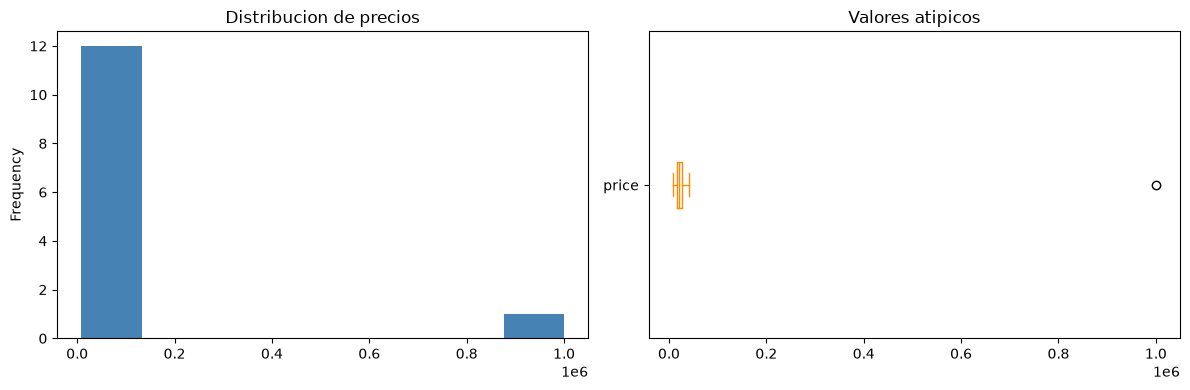

In [38]:
# Histograma y boxplot del precio
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_cars['price'].plot(kind='hist', bins=8, ax=axes[0], color='steelblue', title='Distribucion de precios')
df_cars['price'].plot(kind='box', ax=axes[1], vert=False, color='darkorange', title='Valores atipicos')
plt.tight_layout()
plt.show()

In [39]:
# Calcular limites con el rango intercuartil (IQR)
q1 = df_cars['price'].quantile(0.25)
q3 = df_cars['price'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outliers = df_cars[(df_cars['price'] < lower_limit) | (df_cars['price'] > upper_limit)]
outliers[['brand', 'model', 'price']]

,brand,model,price
12,Ford,Mustang,999999.0


In [40]:
# Dataset limpio sin precios atipicos
df_cars_clean = df_cars[
    (df_cars['price'] >= lower_limit) & (df_cars['price'] <= upper_limit)
].copy()

# 6. Resultado final

In [41]:
# Precio promedio por marca
df_cars_clean.groupby('brand')['price'].mean().sort_values(ascending=False)

brand
Tesla         42000.0
Mazda         27500.0
Honda         24950.0
Toyota        21500.0
Chevrolet     20250.0
Volkswagen    19500.0
Renault       17200.0
Ford          12900.0
Nissan         9800.0
Kia            8500.0
Name: price, dtype: float64

In [42]:
# Vista de los datos listos para analizar
print(f'Autos despues del filtro: {df_cars_clean.shape[0]}')
df_cars_clean

Autos despues del filtro: 12


,brand,model,year,price,mileage,fuel,transmission,car_age,mileage_thousands
0,Toyota,Corolla,2018,18500.0,62000,Gasolina,Automatica,8,62.0
1,Toyota,Camry,2020,24500.0,35000,Gasolina,Automatica,6,35.0
2,Ford,Fiesta,2017,12900.0,78000,Gasolina,Manual,9,78.0
3,Honda,Civic,2019,21000.0,41000,Gasolina,Automatica,7,41.0
4,Honda,Cr-V,2021,28900.0,22000,Hibrido,Automatica,5,22.0
5,Chevrolet,Onix,2020,20250.0,30000,Gasolina,Manual,6,30.0
6,Nissan,Versa,2016,9800.0,95000,Gasolina,Manual,10,95.0
7,Mazda,3,2022,27500.0,12000,Gasolina,Automatica,4,12.0
8,Kia,Rio,2015,8500.0,110000,Gasolina,Manual,11,110.0
9,Volkswagen,Jetta,2019,19500.0,54000,Gasolina,Automatica,7,54.0
